In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject
from src.distance import DistanceCalculator

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

from src.non_euclidean import Riemann, Grassmann, Wasserstein, PersistentHomology
from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster,get_materials_isomers

In [4]:
mp = MaterialsProject(limit=1_500, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], descriptors=["soap"])
df = mp.load()

2026-05-05 10:46:52.400 | INFO     | src.datasets:load:1998 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-05-05 10:46:53.523 | INFO     | src.datasets:_add_descriptors:2371 - Ignoring output_tag=sample_n1800_seed40_stratified since descriptors are attached directly to dataframe.
2026-05-05 10:46:53.524 | INFO     | src.datasets:_add_descriptors:2375 - Extracting unique elements from formulas...
2026-05-05 10:46:53.534 | INFO     | src.datasets:_add_descriptors:2383 - Found 85 unique elements.
2026-05-05 10:46:53.565 | INFO     | src.datasets:_add_descriptors:2444 - Computing SOAP chunk 0 (0 to 1000, normalize=True)...
2026-05-05 10:46:57.201 | INFO     | src.datasets:_add_descriptors:2444 - Computing SOAP chunk 1 (1000 to 1800, normalize=True)...
2026-05-05 10:47:02.107 | INFO     | src.datasets:_add_descriptors:2511 - Added Materials Project descriptor embedding column(s): ['soap_embedding', 'soap_matrix']
2026-05-05 10:47:02.108 | SUCCESS  |

In [5]:
#df = get_materials_isomers(df)

In [6]:
canche_dir = 'data/qm9/isomers_C7H10O2'
dist_engine = DistanceCalculator(cache_dir=canche_dir)
series = df['soap_embedding']
canche_dir = 'hello'
dist_matrix_soap = dist_engine.get_matrix(series, "soap_kernel", force_calculate=True, filename=canche_dir)

2026-05-05 10:47:02.398 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/qm9/isomers_C7H10O2/hello


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_24633/2216338623.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_soap, method='complete')


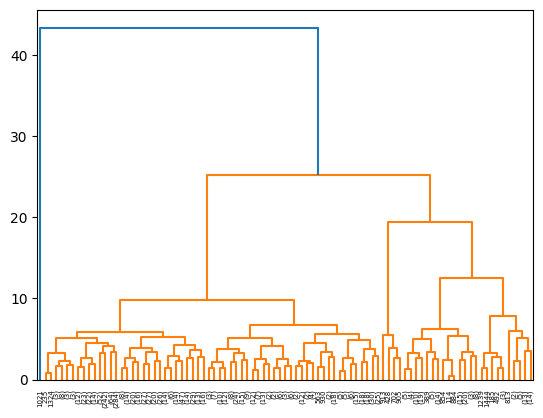

In [7]:
Z = linkage(dist_matrix_soap, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [8]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix_soap)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier_euclidean=labels_hier)

(array([0, 1, 2, 3, 4]), array([  64, 1423,    4,    1,    8]))


In [9]:
create_chemiscope_viewer(df, dist_matrix_soap, labels_hier, 'MDS')

2026-05-05 10:47:03.290 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running MDS dimensionality reduction...
2026-05-05 10:47:03.291 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-05 10:47:15.938 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

In [10]:
average_numeric_by_cluster(df, "labels_hier_euclidean")

shape: (5, 35)
┌───────────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_hier_euclidean ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_

labels_hier_euclidean,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,is_injected,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,64,1.117344,-18.320021,-0.662181,0.642237,5.530902,7.848885,8.246771,10.206549,87.968862,87.576578,91.027859,676.800384,18.640625,0.055026,3.01841,3.104715,0.0,51.5625,7,"""Orthorhombic""",23.4375,35,"""Fm-3m""",17.1875,36,"""AB3""",14.0625,50,"""cF16""",10.9375,1,null,0.0
1,1423,1.587393,-13.292344,-1.313179,0.480226,6.417789,6.622141,7.069132,9.327308,86.695942,87.341846,89.827599,397.894845,25.34364,0.084772,2.272483,2.555651,0.0,61.770907,7,"""Orthorhombic""",23.190443,138,"""P1""",7.308503,471,"""ABC2""",5.762474,436,"""cF16""",3.162333,1,null,0.0
2,4,1.26,-3.303369,-0.580875,0.155225,2.717895,7.779398,10.163557,14.514581,83.194892,84.298013,88.621967,1080.089721,15.75,0.423631,2.720196,2.870966,0.0,25.0,4,"""Orthorhombic""",25.0,4,"""P1""",25.0,4,"""AB2""",25.0,4,"""aP24""",25.0,1,null,0.0
3,1,0.07,-6.373456,0.954623,0.3723,0.131221,14.774487,14.576138,14.576138,59.604298,59.548826,59.548827,2197.804594,4.0,0.954623,3.662385,3.756095,0.0,0.0,1,"""Orthorhombic""",100.0,1,"""Immm""",100.0,1,"""ABC2""",100.0,1,"""oI8""",100.0,1,null,0.0
4,8,1.67125,-10.244354,-1.344655,0.474737,4.318947,7.620204,6.942076,9.630034,80.22918,82.596442,85.83916,517.038838,25.0,0.250684,1.975249,2.461145,0.0,37.5,5,"""Triclinic""",37.5,6,"""P1""",25.0,7,"""AB2""",25.0,7,"""hR39""",25.0,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


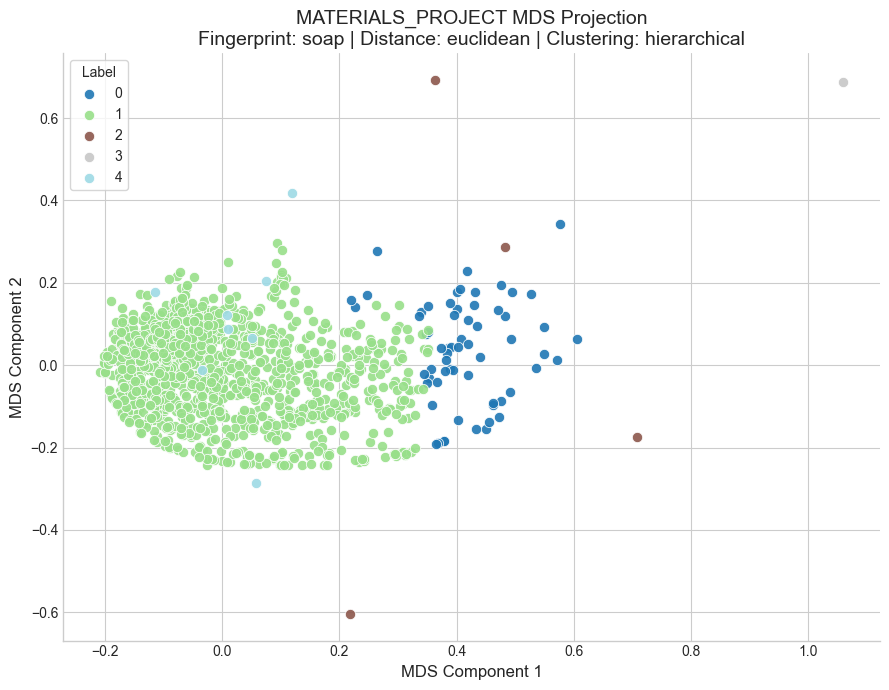

2026-05-05 11:23:49.466 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved MDS projection plot to figures/materials_project/clustering/euclidean/soap/mds_hierarchical_projection.png


In [27]:
_ = _=plot_distance_matrix_projection(
    dist_matrix=dist_matrix_soap,
    fingerprint="soap",
    distance_metric="euclidean",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

# Riemann

In [11]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor="soap")

2026-05-05 10:47:16.455 | INFO     | src.non_euclidean:_load_cached_distance_matrix:405 - Loading cached riemann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/riemann_materials-project_n1500_soap_affine-invariant_nopca.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_24633/2254175340.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_riemann = linkage(dist_matrix_riemann, method='complete')


(array([1, 2, 3, 4, 5], dtype=int32), array([862, 329,  16,  92, 201]))


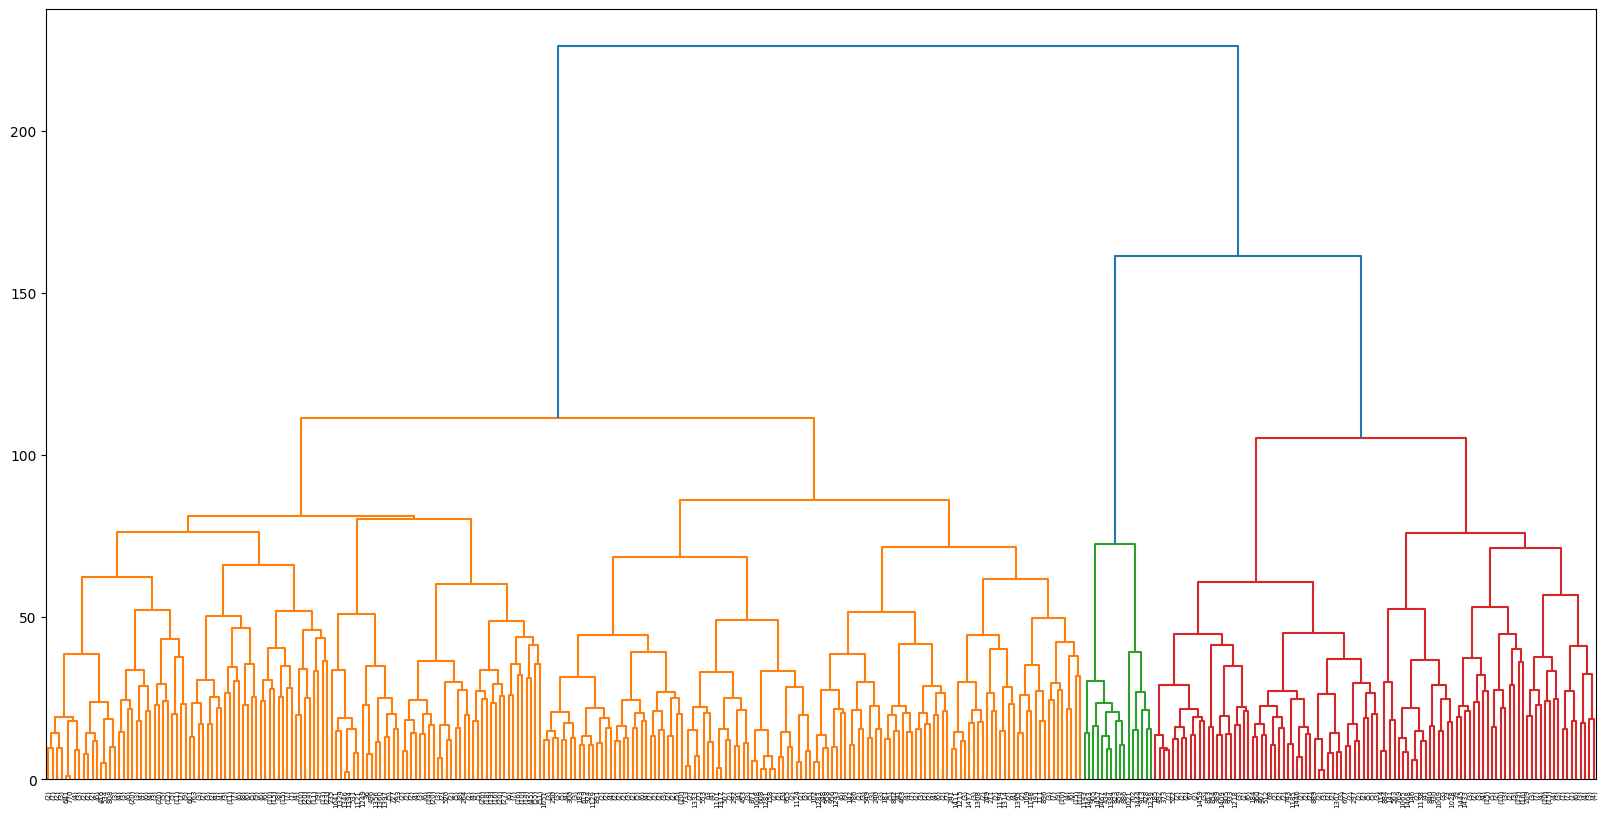

In [12]:
link_riemann = linkage(dist_matrix_riemann, method='complete')
plt.figure(figsize=(20,10))
_=dendrogram(link_riemann, p=8, truncate_mode='level')
labels_riemann = fcluster(link_riemann, t=100, criterion='distance')
df = df.with_columns(labels_riemann=labels_riemann)
print(np.unique(labels_riemann, return_counts=True))

In [13]:
d = average_numeric_by_cluster(df, "labels_riemann")

shape: (5, 36)
┌────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_riemann ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier_euclidean ┆ pct_metal ┆ unique_crystal_systems ┆ top_c

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


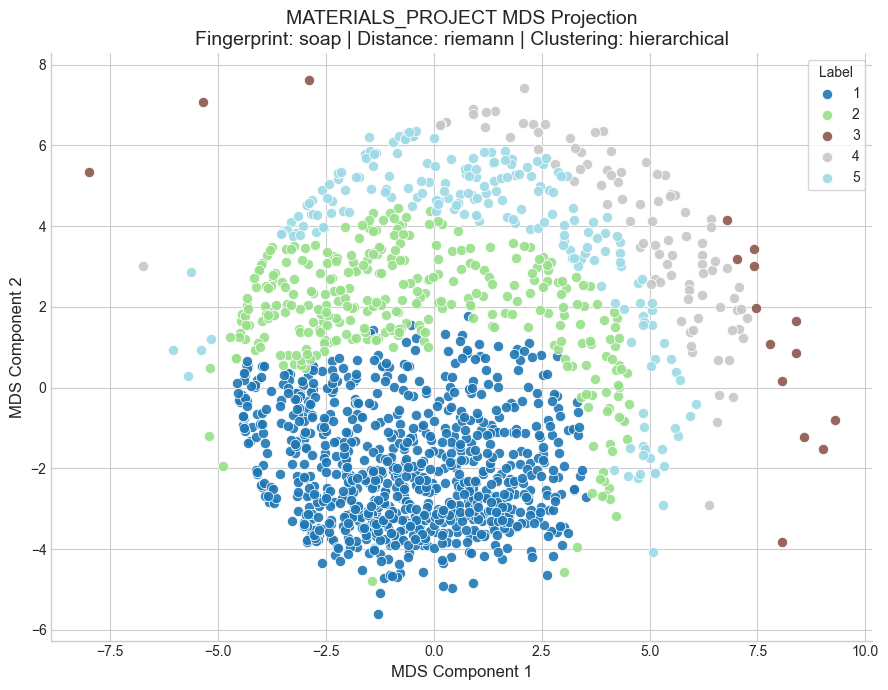

2026-05-05 10:47:34.922 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved MDS projection plot to figures/materials_project/clustering/riemann/soap/mds_hierarchical_projection.png


In [14]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="soap",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_riemann,
    clustering_method="hierarchical"
)

In [15]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_riemann, 'MDS')

2026-05-05 10:47:35.150 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running MDS dimensionality reduction...
2026-05-05 10:47:35.150 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-05 10:47:52.352 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

outliers: Lowest density (1.89), massive volume (1041.8), high number of sites (82.8), high band gap (1.99), and 0% metal.

# Grassmann

In [16]:
grassmann = Grassmann()

In [17]:
dist_matrix_grassmann_right = grassmann.distance_matrix(df=df, descriptor="soap", vector_side='right')

2026-05-05 10:47:52.666 | INFO     | src.non_euclidean:_load_cached_distance_matrix:405 - Loading cached grassmann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/grassmann_materials-project_n1500_soap_k3_svd_right_norm.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_24633/1960638813.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_grassmann = linkage(dist_matrix_grassmann_right, method='complete')


(array([1, 2, 3, 4, 5, 6], dtype=int32), array([  4, 150,  14, 505, 826,   1]))


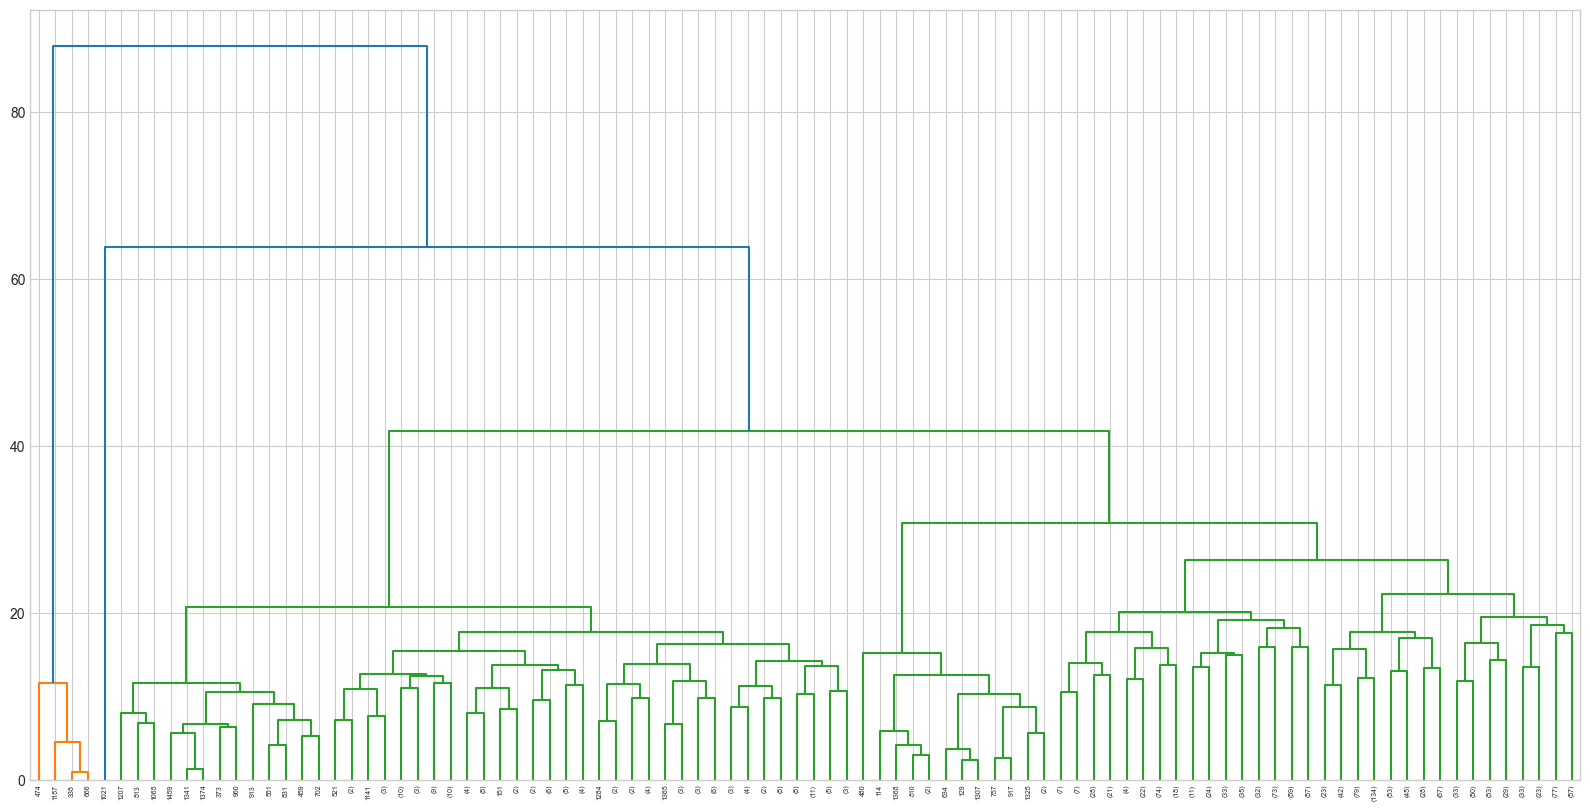

In [18]:
link_grassmann = linkage(dist_matrix_grassmann_right, method='complete')
plt.figure(figsize=(20,10))
dendrogram(link_grassmann, p=8, truncate_mode='level')
labels_grassmann  = fcluster(link_grassmann, t=25, criterion='distance')
df = df.with_columns(labels_grassmann=labels_grassmann)
print(np.unique(labels_grassmann, return_counts=True))

In [19]:
d = average_numeric_by_cluster(df, "labels_grassmann")

shape: (6, 37)
┌──────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────────────────┬────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_grassmann ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier_euclidean ┆ labels_riemann 

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


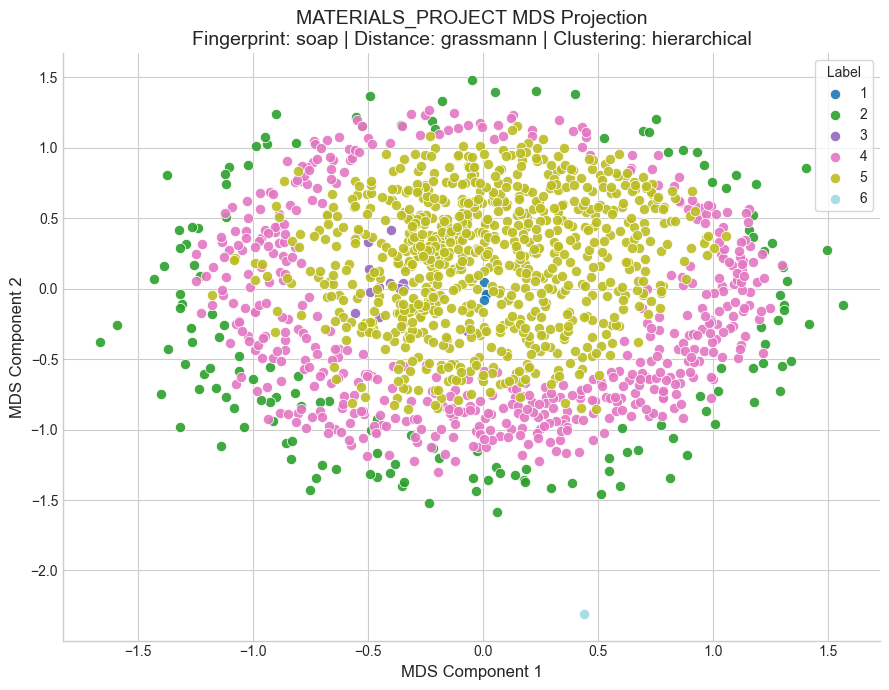

2026-05-05 10:48:11.088 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved MDS projection plot to figures/materials_project/clustering/grassmann/soap/mds_hierarchical_projection.png


In [20]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix_grassmann_right,
    fingerprint="soap",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_grassmann,
    clustering_method="hierarchical"
)

In [21]:
create_chemiscope_viewer(df, dist_matrix_grassmann_right, labels_grassmann, 'MDS')

2026-05-05 10:48:11.123 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running MDS dimensionality reduction...
2026-05-05 10:48:11.124 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-05 10:48:31.592 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

outliers:
-   cluster 1: only 1 site and very high density
-   cluster 4: very low density and massive volume

# Wasserstein

In [22]:
wasserstein = Wasserstein()
dist_matrix_wasserstein = wasserstein.distance_matrix(df=df, descriptor="soap")

2026-05-05 10:48:31.979 | INFO     | src.non_euclidean:_load_cached_distance_matrix:405 - Loading cached wasserstein distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/Materials Project/non_euclidean_cache/wasserstein_materials-project_n1500_soap_sqeuclidean.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_24633/4061179090.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link_wasserstein = linkage(dist_matrix_wasserstein, method='complete')


(array([1, 2, 3, 4, 5, 6], dtype=int32), array([   4,    2,   29,  110, 1354,    1]))


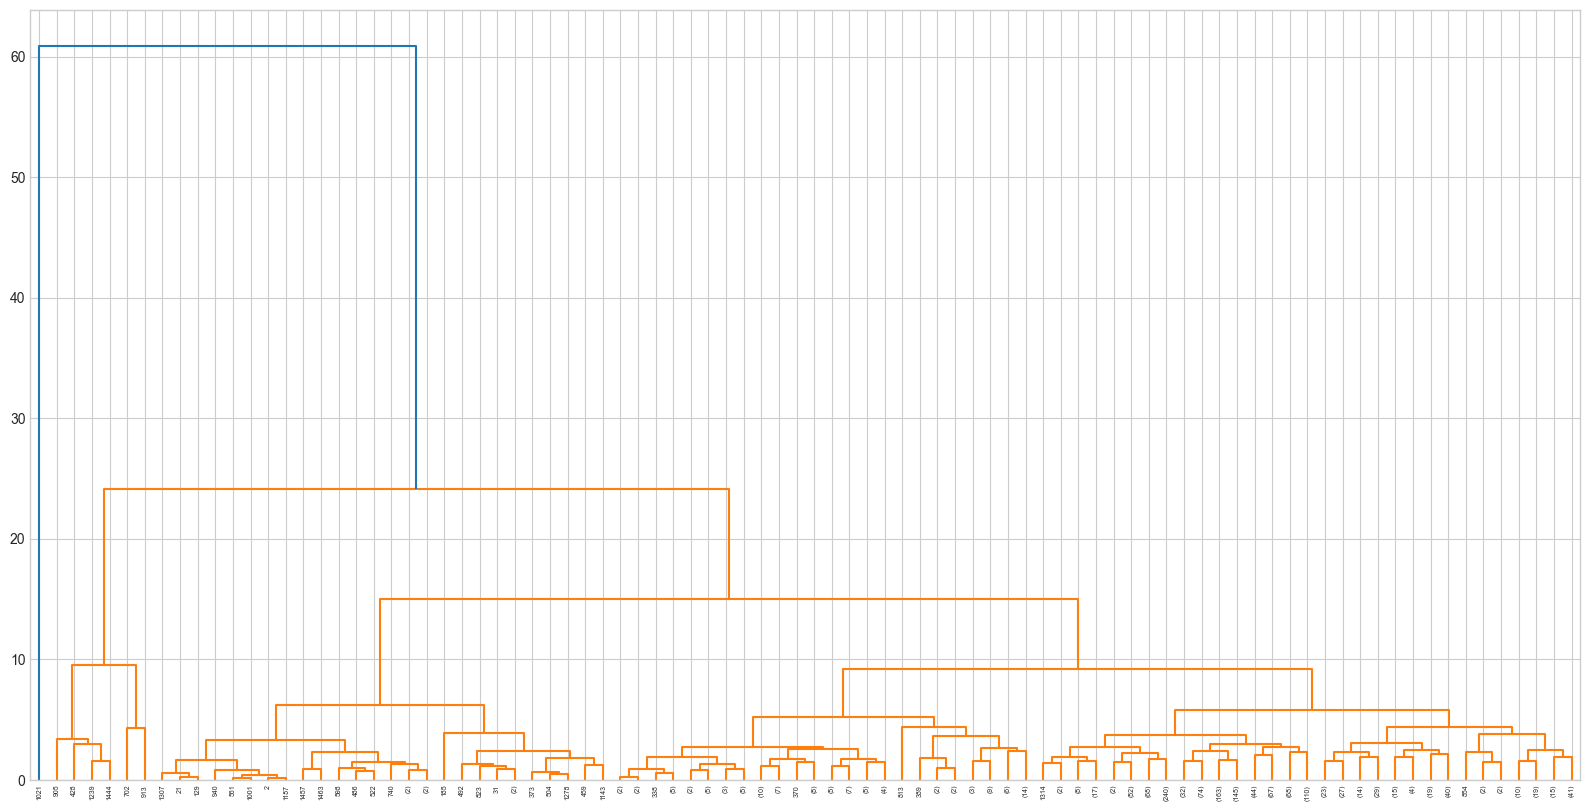

In [23]:
link_wasserstein = linkage(dist_matrix_wasserstein, method='complete')
plt.figure(figsize=(20,10))
dendrogram(link_wasserstein, p=8, truncate_mode='level')
labels_wasserstein  = fcluster(link_wasserstein, t=9, criterion='distance')
df = df.with_columns(labels_wasserstein=labels_wasserstein)
print(np.unique(labels_wasserstein, return_counts=True))

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


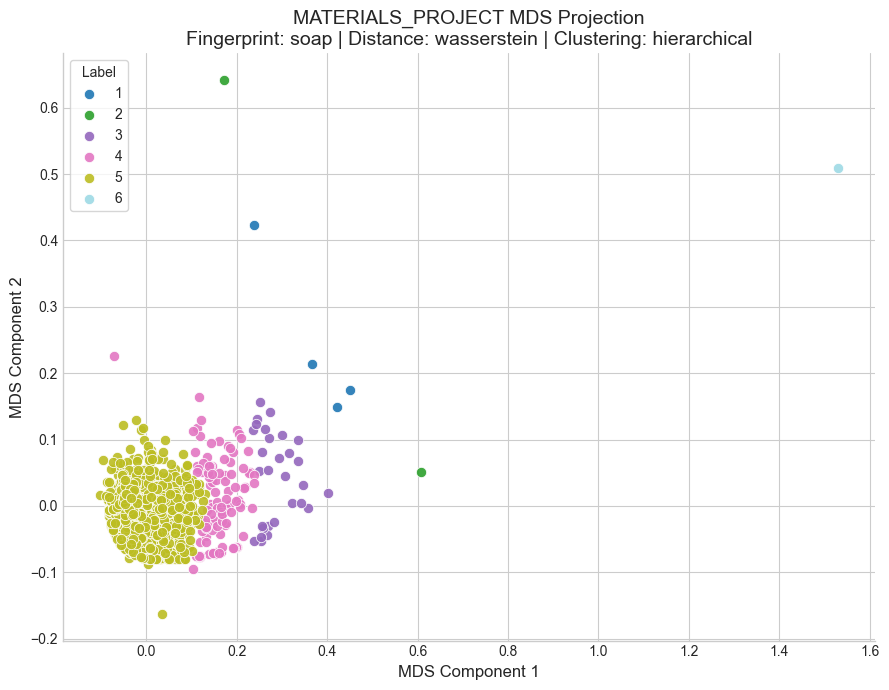

2026-05-05 10:48:49.418 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved MDS projection plot to figures/materials_project/clustering/wasserstein/soap/mds_hierarchical_projection.png


In [24]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasserstein,
    fingerprint="soap",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="materials_project",
    labels=labels_wasserstein,
    clustering_method="hierarchical"
)

In [25]:
create_chemiscope_viewer(df, dist_matrix_wasserstein, labels_wasserstein, 'MDS')

2026-05-05 10:48:49.501 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running MDS dimensionality reduction...
2026-05-05 10:48:49.503 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-05 10:49:06.776 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assemblin

<ChemiscopeWidget(meta={'name': 'Materials Project - MDS Clustering'}, settings={'map': {'x': {'property': 'MD…

In [26]:
d = average_numeric_by_cluster(df, "labels_wasserstein")

shape: (6, 38)
┌────────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────────────────┬────────────────┬──────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_wasserstein ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha   ┆ beta    ┆ gamma    ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier_eu